# Exploratory Data Analysis

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

## Problem Definition
We want to predict whether a person earns more than $50K per year and provide simple recommendations to help improve income based on education, occupation, and work characteristics.

# Read data and create DataFrame

In [23]:
df = pd.read_csv("/workspaces/josefina-aispuro-merelles-machine-learning/data/raw/adult-census-income.csv.csv")
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Descriptive Analysis

In [24]:
# Check the dimensions
df.shape

(32561, 15)

In [25]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [26]:
# Generate a statistical summary of numerical columns and transpose it for readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


### Observations
- There are 32561 rows and 15 columns.
- No missing values.
- The data contains 6 numerical features and 9 objects.

## Data Cleaning

In [27]:
# Looking for duplicated data
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool

In [28]:
# Dropping duplicates if True
if df.duplicated().sum():
        df = df.drop_duplicates()
        
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


### Observations
We removed 24 duplicates.

In [29]:
df["workclass"].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [30]:
df["occupation"].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [31]:
# Replace missing categorical values represented as "?" with the category "Unknown"
df["occupation"] = df["occupation"].replace("?", "Unknown")
df["workclass"] = df["workclass"].replace("?", "Unknown")

/tmp/ipykernel_950/1600868916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["occupation"] = df["occupation"].replace("?", "Unknown")
/tmp/ipykernel_950/1600868916.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["workclass"] = df["workclass"].replace("?", "Unknown")


### Observations
Missing values in the categorical variables occupation and workclass were replaced with a new category labeled "Unknown". This approach preserves all observations in the dataset and allows the model to learn potential patterns associated with missing information, avoiding data loss and reducing the risk of introducing bias.

In [32]:
# Drop columns that are not relevant for predicting income
df = df.drop(columns=["fnlwgt", "education"])

### Observations
- We removed fnlwgt because it is just a census sampling weight and does not reflect personal characteristics.
- We removed education because its numerical counterpart education.num already encodes the same information, avoiding redundancy.

## Visualization

In [33]:
# Convert income to numeric: 0 for <=50K, 1 for >50K
df["income_num"] = df["income"].apply(lambda x: 0 if x == "<=50K" else 1)

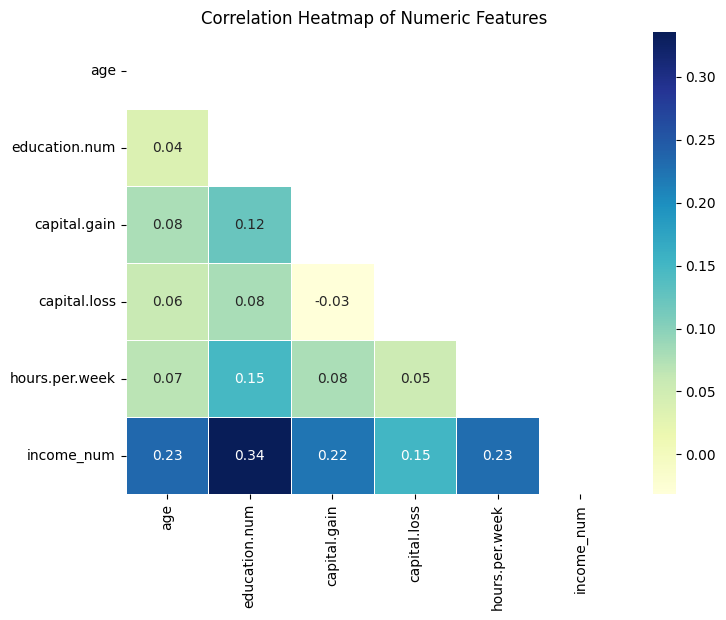

In [34]:
# Correlation matrix for numeric features
numeric_cols = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week", "income_num"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

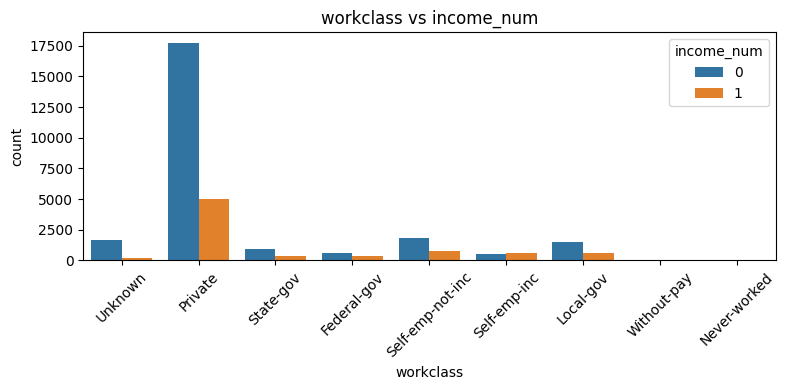

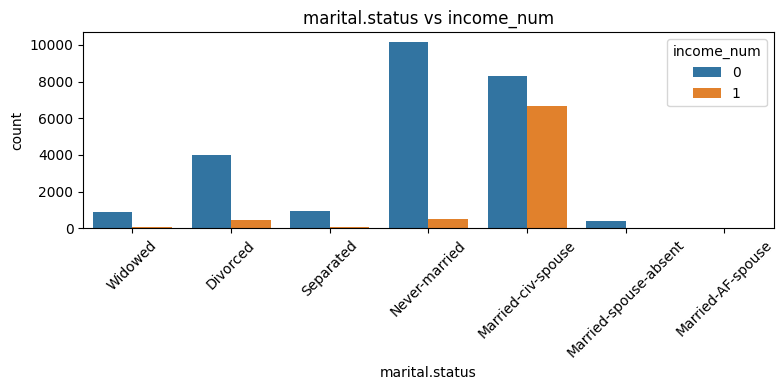

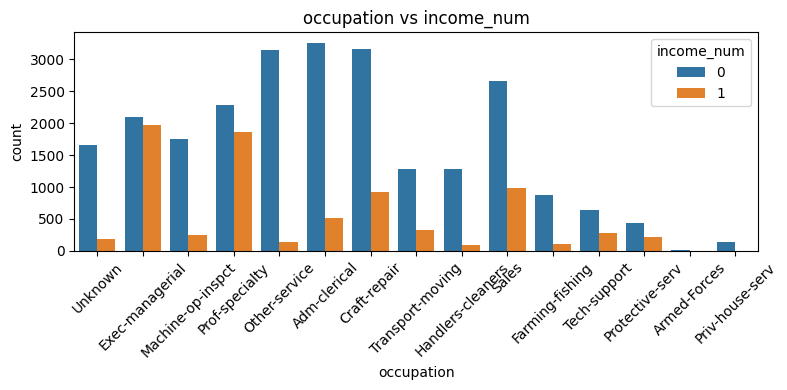

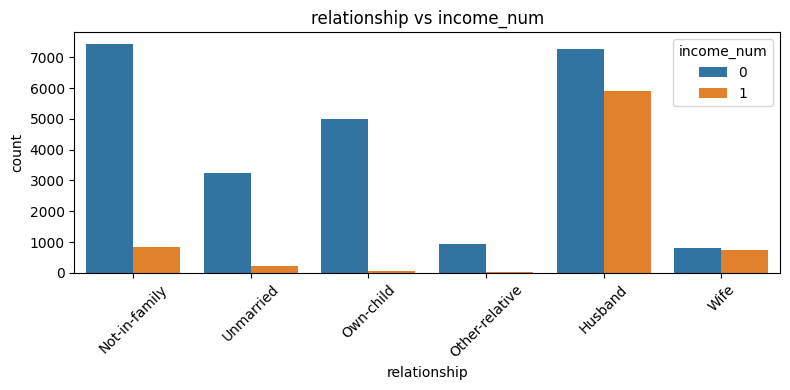

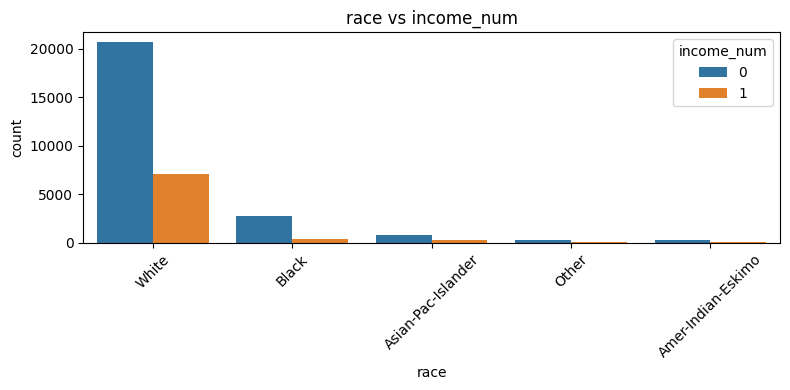

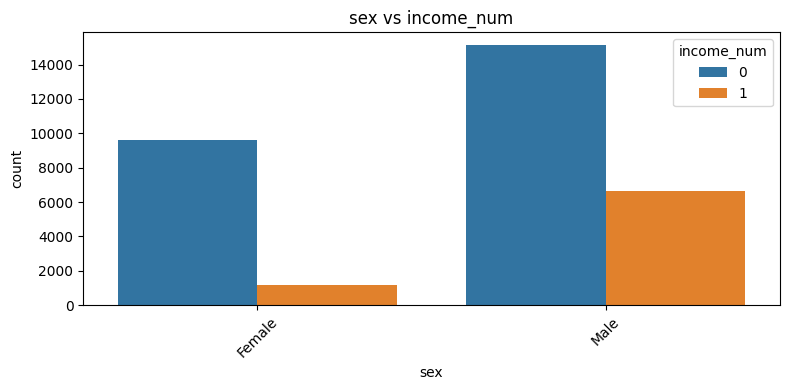

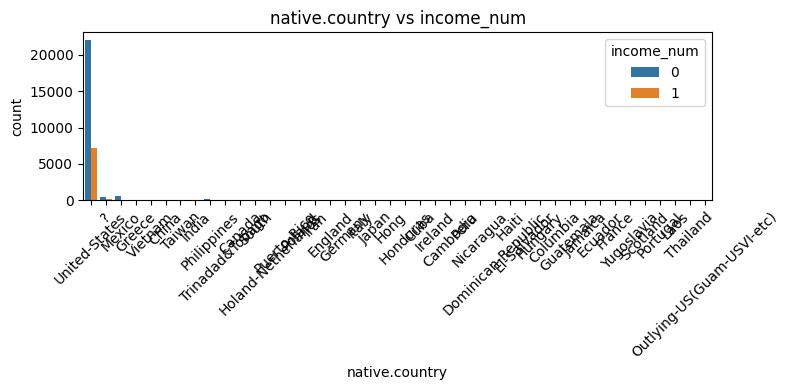

In [35]:
# Visualization for categorical features
cat_cols = ["workclass", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="income_num")
    plt.title(f"{col} vs income_num")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Train / Test Split

In [36]:
# Define X (features) and y (target)
X = df.drop(columns=["income", "income_num"])
y = df["income_num"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## One Hot Encoding

In [37]:
# Encode categorical columns
cat_columns = cat_cols
encoder = OneHotEncoder(sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[cat_columns])
X_test_encoded = encoder.transform(X_test[cat_columns])

X_train_one_hot = pd.DataFrame(X_train_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_train.index)
X_test_one_hot = pd.DataFrame(X_test_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_test.index)

X_train_final = pd.concat([X_train.drop(columns = cat_columns), X_train_one_hot], axis=1)
X_test_final  = pd.concat([X_test.drop(columns = cat_columns), X_test_one_hot], axis=1)

## Feature Scaling

In [38]:
scaler = StandardScaler()
scaler.fit(X_train_final)
X_train_scaled = scaler.transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train_final.columns, index = X_train_final.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns = X_test_final.columns, index = X_test_final.index)

X_train_scaled.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
32239,0.175224,-0.424522,-0.147221,-0.217763,0.772045,-0.175878,-0.2615,-0.016401,-1.516792,5.314703,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
30377,-0.703437,1.134104,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
5455,0.321668,-0.424522,-0.147221,-0.217763,3.033711,-0.175878,-0.2615,-0.016401,-1.516792,5.314703,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,46.562682,-0.020562,-2.946762,-0.046434,-0.023198
19698,0.541333,0.354791,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
23193,-0.630215,-0.034865,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198


## Prepare content features

In [39]:
content_cols = ["education.num", "hours.per.week"] + [c for c in X_train_final.columns if "occupation" in c or "workclass" in c]
X_content_train = X_train_final[content_cols]
X_content_test  = X_test_final[content_cols]

## Recommendation function

In [40]:
def recommend_user(user, X_train, y_train, top_k=5):
    sims = cosine_similarity(user.values.reshape(1, -1), X_train)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    top_high_income = [i for i in top_idx if y_train.iloc[i] == 1]
    
    top_occupations = pd.Series([c for i in top_high_income for c in X_train.columns if "occupation" in c and X_train.iloc[i][c] > 0]).value_counts().head(3).index.tolist()
    top_workclass   = pd.Series([c for i in top_high_income for c in X_train.columns if "workclass" in c and X_train.iloc[i][c] > 0]).value_counts().head(3).index.tolist()
    
    return top_occupations, top_workclass

### Example with simulated user

In [43]:
sim_user = X_content_test.iloc[0]
rec_occupations, rec_workclass = recommend_user(sim_user, X_content_train, y_train, top_k=10)
rec_occupations, rec_workclass

(['occupation_Machine-op-inspct'], ['workclass_Private'])